# Analisis Data Polutan Udara di Wilayah Minahasa/Manado

Dokumen ini menyajikan analisis terhadap enam jenis polutan udara (CO, NO2, HCHO, O3, SO2, dan CH4) di wilayah Minahasa/Manado dengan memanfaatkan data satelit Sentinel-5P. Pembahasan pada tugas ini dibatasi hingga tahap Business Understanding dan Data Understanding.

## 1. Business Understanding

### 1.1 Latar Belakang

Pemantauan kualitas udara merupakan hal penting untuk dilakukan, mengingat polutan di atmosfer dapat berasal dari aktivitas manusia (transportasi, industri, pembakaran, maupun pertanian) atau dari proses alami seperti aktivitas vulkanik. Kombinasi sumber tersebut dapat berbeda-beda antarwilayah, bergantung pada karakteristik masing-masing daerah.

Analisis pada tugas ini difokuskan pada enam jenis polutan udara di wilayah Minahasa/Manado dengan memanfaatkan data Sentinel-5P selama periode pengamatan kurang lebih satu tahun.

### 1.2 Tujuan Analisis

1. Mengumpulkan data enam polutan udara sepanjang periode pengamatan yang ditentukan.
2. Mengamati perkembangan konsentrasi masing-masing polutan dari waktu ke waktu.
3. Mengidentifikasi kemungkinan sumber emisi dari tiap polutan.
4. Melakukan tahap Data Understanding, mencakup pemeriksaan struktur data, missing value, outlier, dan visualisasi time series.

### 1.3 Manfaat Analisis

Hasil analisis ini diharapkan dapat memberikan gambaran awal mengenai kondisi kualitas udara di Minahasa/Manado, sekaligus membantu mengenali pola konsentrasi polutan sepanjang waktu. Temuan pada tahap ini juga dapat menjadi landasan bagi tahap analisis lanjutan, misalnya pemodelan atau prediksi kualitas udara.

### 1.4 Penjelasan dan Kemungkinan Sumber Tiap Polutan

| Polutan | Apa Itu? | Kemungkinan Sumber |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tak berwarna dan tak berbau, muncul dari pembakaran bahan bakar yang tidak sempurna. Berbahaya karena mengikat hemoglobin lebih kuat dari oksigen. | Kendaraan bermotor, kebakaran lahan/hutan, pembakaran biomassa |
| **NO2** (Nitrogen Dioksida) | Gas coklat kemerahan berbau tajam, terbentuk dari oksidasi NO di udara. Ikut memicu hujan asam dan pembentukan ozon permukaan. | Kendaraan bermotor, industri, pembangkit listrik |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC), sering dipakai sebagai penanda tak langsung emisi VOC di atmosfer. | Emisi vegetasi, pembakaran biomassa, kendaraan, industri |
| **O3** (Ozon Permukaan) | Bukan gas yang langsung diemisikan, melainkan polutan sekunder hasil reaksi fotokimia NOx dan VOC dengan bantuan sinar matahari. | Reaksi emisi kendaraan/industri (NOx, VOC) dengan sinar matahari |
| **SO2** (Sulfur Dioksida) | Gas tak berwarna berbau tajam, dihasilkan dari pembakaran bahan bakar yang mengandung sulfur. | Pembakaran bahan bakar fosil, industri, aktivitas vulkanik |
| **CH4** (Metana) | Gas rumah kaca dengan efek pemanasan jauh lebih kuat dari CO2, tak berwarna dan tak berbau. | Pertanian (sawah), peternakan, TPA, kebocoran gas alam |


### 1.5 Deskripsi Data

- Sumber data: Sentinel-5P (`SENTINEL_5P_L2`), diakses melalui layanan openEO pada Copernicus Data Space Ecosystem.
- Cakupan wilayah: Minahasa/Manado, dibatasi menggunakan polygon GeoJSON yang dibuat lewat geojson.io.
- Periode pengamatan yang ditargetkan: 31 Agustus 2025 s.d. 31 Agustus 2026 (realisasi akhirnya sedikit berbeda, lihat Bagian 2.2).
- Polutan yang diamati: CO, NO2, HCHO, O3, SO2, dan CH4, masing-masing dalam bentuk rata-rata harian untuk seluruh wilayah kajian.
- Keluaran: berkas `.csv` dengan kolom `date, CO, NO2, HCHO, O3, SO2, CH4`.

## 2. Data Understanding

### 2.1 Pengumpulan Data

Data diperoleh dari koleksi `SENTINEL_5P_L2` melalui openEO. Pengambilan dilakukan per polutan secara terpisah, kemudian hasilnya digabungkan menjadi satu tabel berdasarkan kolom tanggal.

In [ ]:
# library openeo untuk ambil data satelit, netCDF4 untuk baca hasil unduhannya
!pip install openeo netCDF4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.1 MB/s eta 0:00:00


Menjalankan sel di bawah ini akan menampilkan tautan autentikasi. Buka tautan tersebut, login menggunakan akun Copernicus, lalu kembali ke notebook untuk melanjutkan.

In [ ]:
import openeo
import netCDF4
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

**penjelasan code:**

* Pustaka `openeo` digunakan untuk menghubungkan notebook ke server Copernicus tempat data Sentinel-5P disimpan.
* Baris terakhir sekaligus membuka koneksi dan melakukan proses autentikasi (login).

#### 2.1.1 Wilayah Penelitian (Area of Interest)

Batas wilayah kajian disusun dari polygon GeoJSON yang dibuat melalui geojson.io. Polygon tersebut digunakan untuk menghitung rata-rata polutan di dalam area kajian, sedangkan bounding box berfungsi sebagai batas awal saat data ditarik dari server.

> 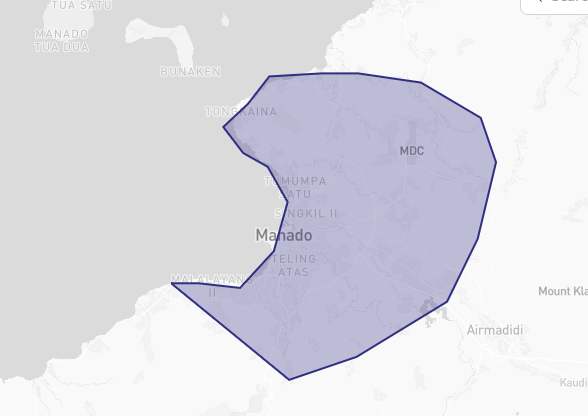

In [ ]:
AOI = {
    "type": "Polygon",
    "coordinates": [[
        [124.8313269, 1.5946258], [124.8171763, 1.5764393],
        [124.8010043, 1.5612837], [124.8141441, 1.5441072],
        [124.8303161, 1.5350137], [124.8434559, 1.5117746],
        [124.8343591, 1.4794415], [124.8121226, 1.4551914],
        [124.7848323, 1.4582227], [124.7666387, 1.4582227],
        [124.8444667, 1.394565],  [124.8889398, 1.4097217],
        [124.9485742, 1.4460975], [124.9687892, 1.4875248],
        [124.9809183, 1.5380448], [124.9708108, 1.5673459],
        [124.9313914, 1.5905844], [124.8899505, 1.5966466],
        [124.8656925, 1.5966466], [124.8313269, 1.5946258],
    ]]
}

titik = AOI["coordinates"][0]
lons = [p[0] for p in titik]
lats = [p[1] for p in titik]

BBOX = {"west": min(lons), "south": min(lats),
        "east": max(lons), "north": max(lats)}

**penjelasan code:**

* `AOI` merupakan polygon yang menandai batas wilayah Minahasa/Manado.
* `BBOX` adalah kotak pembatas terluar dari polygon tersebut, digunakan server untuk membatasi area yang diunduh.

#### 2.1.2 Periode dan Daftar Polutan

Data ditargetkan untuk periode satu tahun hingga 31 Agustus 2026, yaitu 31 Agustus 2025 – 31 Agustus 2026. Nilai `END_DATE` ditulis `2026-09-01` karena batas akhir bersifat exclusive, sehingga tanggal 31 Agustus tetap ikut terambil.

In [ ]:
START_DATE = "2025-08-31"
END_DATE = "2026-09-01"   # supaya 31 Agustus 2026 tetap terambil

POLLUTANTS = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

#### 2.1.3 Fungsi Pengambilan dan Pembacaan Data

Fungsi `ambil_data()` menarik data satu polutan dari Sentinel-5P, menghitung rata-rata harian kemudian rata-rata spasial untuk seluruh AOI, dan menyimpan hasilnya sebagai berkas NetCDF.

Fungsi `baca_nc()` membaca berkas NetCDF tersebut menjadi tabel berisi kolom tanggal dan nilai polutan. Karena struktur dimensi tiap berkas NetCDF dapat berbeda antarpolutan, fungsi ini secara otomatis mencari dimensi yang panjangnya sesuai dengan jumlah tanggal untuk ditetapkan sebagai dimensi waktu. Dimensi lain di luar dimensi waktu kemudian dirata-ratakan agar setiap tanggal hanya memiliki satu nilai.

In [ ]:
def ambil_data(polutan):
    data = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[START_DATE, END_DATE],
        spatial_extent=BBOX,
        bands=[polutan]
    )

    data_harian = data.aggregate_temporal_period(
        reducer="mean",
        period="day"
    )

    data_wilayah = data_harian.aggregate_spatial(
        reducer="mean",
        geometries=AOI
    )

    file_output = f"{polutan}_Manado.nc"

    data_wilayah.execute_batch(
        title=f"Data {polutan}",
        outputfile=file_output
    )

    return file_output


def baca_nc(file, polutan):
    data = netCDF4.Dataset(file)

    nilai = np.ma.filled(
        data.variables[polutan][:],
        np.nan
    )

    waktu = data.variables["t"]
    tanggal = netCDF4.num2date(
        waktu[:],
        units=waktu.units
    )

    jumlah_tanggal = len(tanggal)

    # cari dimensi yang panjangnya sama dengan jumlah tanggal -> itu dimensi waktu
    time_axis = next(
        (axis for axis, ukuran in enumerate(nilai.shape)
         if ukuran == jumlah_tanggal),
        None
    )

    if time_axis is None:
        raise ValueError(
            f"Dimensi waktu tidak ditemukan. Shape: {nilai.shape}"
        )

    nilai = np.moveaxis(nilai, time_axis, 0)

    if nilai.ndim > 1:
        nilai = np.nanmean(
            nilai,
            axis=tuple(range(1, nilai.ndim))
        )

    return pd.DataFrame({
        "date": [x.strftime("%Y-%m-%d") for x in tanggal],
        polutan: nilai
    })

**penjelasan code:**

* `ambil_data()` melakukan query data mentah dari `SENTINEL_5P_L2`, mengagregasinya menjadi rata-rata harian per wilayah, lalu menyimpannya sebagai berkas `.nc`.
* `baca_nc()` membuka berkas `.nc`, mengonversi nilai kosong menjadi NaN, menyesuaikan dimensi waktu dengan jumlah tanggal, kemudian mengembalikan hasilnya sebagai tabel berisi tanggal dan nilai polutan.

#### 2.1.4 Menjalankan Pengambilan untuk Seluruh Polutan

Setiap polutan diproses satu per satu, kemudian digabungkan berdasarkan kolom `date` dan disimpan dalam format CSV.

In [ ]:
df = None

for polutan in POLLUTANTS:
    print(f"Mengambil: {polutan}")

    file = ambil_data(polutan)
    data = baca_nc(file, polutan)

    if df is None:
        df = data
    else:
        df = df.merge(data, on="date", how="outer")

df = df.sort_values("date").reset_index(drop=True)
df.to_csv("pollutant_data_manado.csv", index=False)

print("\nData berhasil disimpan!")
print("Tanggal pertama:", df["date"].min())
print("Tanggal terakhir:", df["date"].max())
print("Jumlah baris:", len(df))

Mengambil: CO
0:00:00 Job 'j-260904071758433ea70183445e0f0f81': send 'start'
0:00:05 Job 'j-260904071758433ea70183445e0f0f81': queued (progress 0%)
0:00:10 Job 'j-260904071758433ea70183445e0f0f81': queued (progress 0%)
0:00:17 Job 'j-260904071758433ea70183445e0f0f81': queued (progress 0%)
0:00:25 Job 'j-260904071758433ea70183445e0f0f81': queued (progress 0%)
0:00:35 Job 'j-260904071758433ea70183445e0f0f81': queued (progress 0%)
0:00:47 Job 'j-260904071758433ea70183445e0f0f81': queued (progress 0%)
0:01:03 Job 'j-260904071758433ea70183445e0f0f81': queued (progress 0%)
0:01:22 Job 'j-260904071758433ea70183445e0f0f81': running (progress N/A)
0:01:46 Job 'j-260904071758433ea70183445e0f0f81': running (progress N/A)
0:02:16 Job 'j-260904071758433ea70183445e0f0f81': running (progress N/A)
0:02:53 Job 'j-260904071758433ea70183445e0f0f81': running (progress N/A)
0:03:40 Job 'j-260904071758433ea70183445e0f0f81': running (progress N/A)
0:04:39 Job 'j-260904071758433ea70183445e0f0f81': finished (p

**penjelasan code:**

* Iterasi dilakukan untuk setiap polutan, kemudian digabungkan menggunakan `merge(..., how="outer")` agar tanggal yang tidak memiliki nilai pada satu polutan tetap tersimpan sebagai NaN, bukan hilang dari tabel.
* Hasil akhirnya diurutkan berdasarkan tanggal, lalu disimpan ke berkas `pollutant_data_manado.csv`.

### 2.2 Struktur dan Isi Data

Mulai bagian ini, data dibaca kembali dari berkas CSV yang telah tersimpan sehingga notebook dapat dijalankan ulang dari titik ini tanpa perlu mengunduh data dari awal. Selanjutnya dilakukan pemeriksaan struktur data, meliputi jumlah baris, nama kolom, tipe data, dan rentang tanggal.

In [ ]:
df = pd.read_csv("pollutant_data_manado.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

POLLUTANTS = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]
df.head()

,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.025826,0.000003,0.000119,0.115216,-0.000039,NaN
1,2025-09-01,NaN,NaN,NaN,0.114812,NaN,NaN
2,2025-09-02,0.024364,NaN,0.000059,0.112275,-0.000109,NaN
3,2025-09-03,0.019973,NaN,0.000032,0.113091,0.000103,NaN
4,2025-09-04,0.022163,NaN,0.000040,0.112525,NaN,NaN


In [ ]:
print(f"Jumlah baris: {len(df)}")
print(f"Kolom: {list(df.columns)}")
print(f"Rentang tanggal: {df['date'].min().date()} s.d. {df['date'].max().date()}")
print()
print("Tipe data per kolom:")
print(df.dtypes)

Jumlah baris: 364
Kolom: ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']
Rentang tanggal: 2025-08-31 s.d. 2026-08-31

Tipe data per kolom:
date    datetime64[ns]
CO             float64
NO2            float64
HCHO           float64
O3             float64
SO2            float64
CH4            float64
dtype: object


In [ ]:
# cek tanggal mana saja yang tidak ada di data (hilang total di semua polutan)
semua_tanggal = pd.date_range(start=df["date"].min(), end=df["date"].max())
tanggal_hilang = semua_tanggal.difference(df["date"])
print(f"Jumlah tanggal hilang: {len(tanggal_hilang)}")
print(tanggal_hilang)

Jumlah tanggal hilang: 2
DatetimeIndex(['2025-09-20', '2026-04-15'], dtype='datetime64[ns]', freq=None)


**penjelasan code:**

* `pd.date_range()` menghasilkan daftar seluruh tanggal dari awal hingga akhir periode data secara berurutan tanpa ada yang terlewat.
* `.difference(df["date"])` membandingkan daftar tersebut dengan tanggal yang benar-benar tercatat di `df`, sehingga diperoleh tanggal yang hilang sepenuhnya (tidak memiliki nilai pada satu pun polutan).

Data yang berhasil terekam mencakup rentang penuh 31 Agustus 2025 – 31 Agustus 2026, sesuai target satu tahun yang ditetapkan sebelumnya. Meski demikian, terdapat dua tanggal (20 September 2025 dan 15 April 2026) yang sama sekali tidak memiliki observasi pada keenam polutan, kemungkinan karena wilayah kajian tertutup awan secara penuh pada tanggal-tanggal tersebut. Setelah memperhitungkan hal ini, dataset akhir yang tersimpan berjumlah 364 baris, dari total 366 hari kalender pada rentang tersebut.

### 2.3 Statistik Deskriptif

In [ ]:
print("Statistik deskriptif:")
df[POLLUTANTS].describe()

Statistik deskriptif:


,CO,NO2,HCHO,O3,SO2,CH4
count,253.000000,217.000000,266.000000,360.000000,257.000000,11.000000
mean,0.024989,0.000008,0.000126,0.114451,0.000011,1885.325974
std,0.003242,0.000005,0.000093,0.005386,0.000096,17.910926
min,0.018206,-0.000007,-0.000127,0.105557,-0.000466,1854.022095
25%,0.022710,0.000005,0.000071,0.109565,-0.000027,1876.892831
50%,0.024879,0.000008,0.000114,0.114023,0.000006,1883.358667
75%,0.026668,0.000011,0.000165,0.118685,0.000051,1891.706775
max,0.036141,0.000025,0.000681,0.125313,0.000636,1921.479248


Terlihat bahwa skala nilai antarpolutan berbeda cukup jauh — CH4 berada pada kisaran ribuan (rata-rata ≈ 1.885), sementara NO2 dan SO2 berada pada kisaran 0,00001 (rata-rata masing-masing 0,000008 dan 0,000011). Perbedaan ini wajar mengingat satuan konsentrasi tiap gas memang tidak sama, dan menjadi alasan mengapa grafik time series pada bagian berikutnya perlu dinormalisasi terlebih dahulu agar dapat dibandingkan pada satu sumbu yang sama.

### 2.4 Missing Value

Data satelit rentan memiliki missing value, umumnya disebabkan oleh tutupan awan yang tebal, kualitas observasi yang rendah, atau data yang telah difilter melalui proses QA (quality assurance) oleh Sentinel-5P.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"jumlah_null": missing, "persen_null": missing_pct})
missing_summary

,jumlah_null,persen_null
date,0,0.00
CO,111,30.49
NO2,147,40.38
HCHO,98,26.92
O3,4,1.10
SO2,107,29.40
CH4,353,96.98


Persentase missing value bervariasi antarpolutan: NO2 sekitar 40,38%, CO 30,49%, SO2 29,4%, dan HCHO 26,92%. Kondisi yang paling mencolok terdapat pada CH4, yang datanya kosong hingga sekitar 96,98%. Hal ini diduga karena band CH4 pada Sentinel-5P memang jarang memiliki cakupan atau kualitas observasi yang memadai untuk wilayah sekecil Minahasa/Manado, ditambah gangguan tutupan awan tropis yang cukup sering terjadi.

Karena jumlah data yang tersedia sangat terbatas, kesimpulan mengenai CH4 belum dapat diambil secara meyakinkan pada tahap ini, dan hal tersebut dicatat sebagai salah satu keterbatasan data. Penanganan missing value (seperti imputasi atau penghapusan) belum dilakukan pada tahap ini karena cakupan tugas masih dibatasi hingga Data Understanding.

### 2.5 Deteksi Outlier / Data Aneh

Pemeriksaan outlier dilakukan menggunakan metode IQR: nilai yang berada di bawah `Q1 - 1.5×IQR` atau di atas `Q3 + 1.5×IQR` dikategorikan sebagai outlier. Nilai ekstrem tersebut tidak langsung dihilangkan karena berpotensi mencerminkan kondisi nyata, misalnya lonjakan polusi akibat kebakaran lahan.

In [ ]:
outlier_summary = []

for pol in POLLUTANTS:
    q1, q3 = df[pol].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_outlier = ((df[pol] < lower) | (df[pol] > upper)).sum()
    n_valid = df[pol].notna().sum()

    outlier_summary.append({
        "polutan": pol,
        "jumlah_outlier": n_outlier,
        "persen_outlier": round(n_outlier / n_valid * 100, 2) if n_valid else 0
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,polutan,jumlah_outlier,persen_outlier
0,CO,3,1.19
1,NO2,7,3.23
2,HCHO,13,4.89
3,O3,0,0.00
4,SO2,18,7.00
5,CH4,2,18.18


**penjelasan code:**

* Batas atas dan bawah outlier dihitung menggunakan metode IQR, kemudian dihitung jumlah data yang berada di luar rentang tersebut untuk masing-masing polutan.

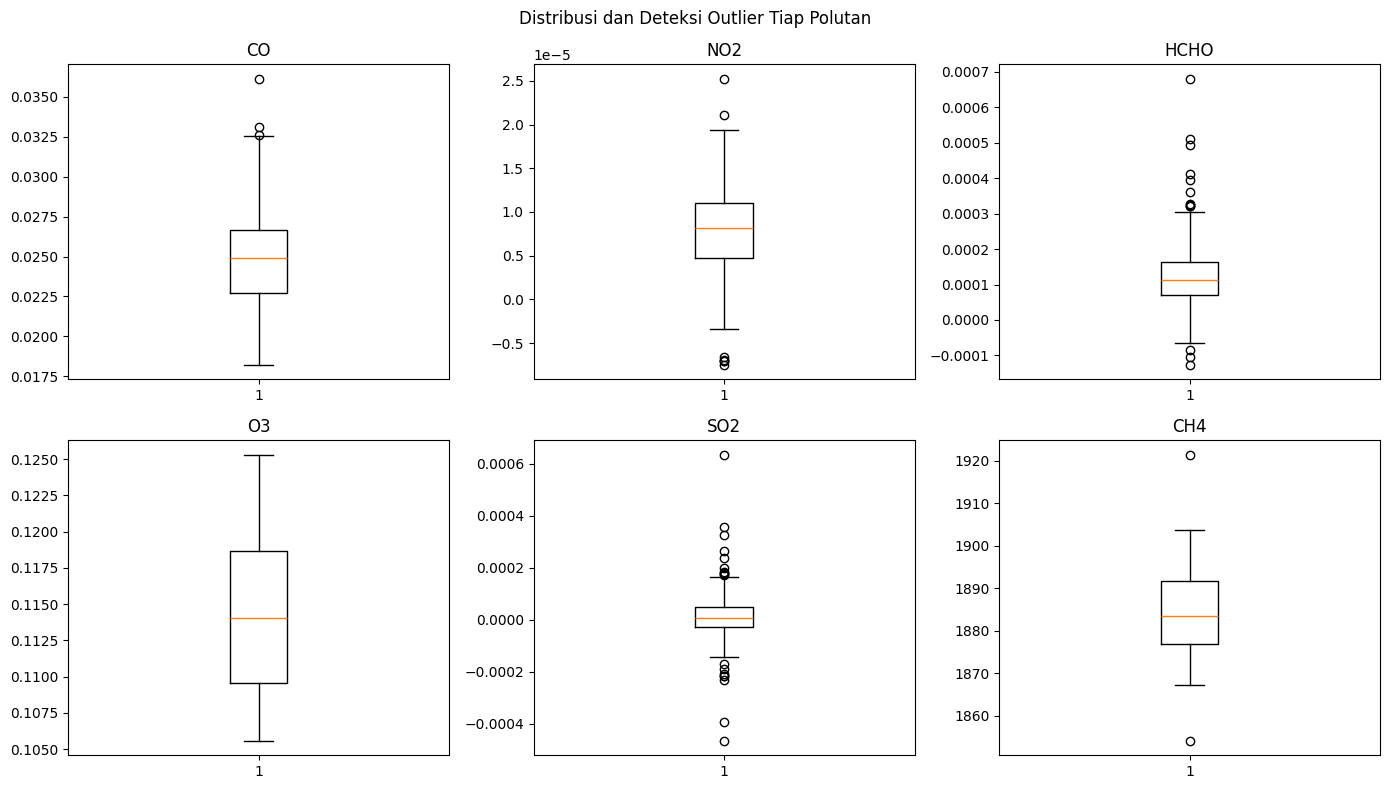

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, pol in zip(axes, POLLUTANTS):
    ax.boxplot(df[pol].dropna(), vert=True)
    ax.set_title(pol)

fig.suptitle("Distribusi dan Deteksi Outlier Tiap Polutan")
plt.tight_layout()
plt.show()

Berdasarkan tabel maupun boxplot, jumlah outlier pada sebagian besar polutan tergolong kecil — O3 bahkan tidak menunjukkan outlier sama sekali, sementara HCHO dan SO2 memiliki proporsi outlier yang relatif lebih tinggi dibanding polutan lain, ditunjukkan oleh banyaknya titik di luar whisker pada kedua arah boxplot-nya. Outlier pada CH4 perlu dimaknai secara hati-hati, mengingat jumlah data valid pada polutan ini sangat sedikit, sehingga persentase outlier yang tampak tinggi belum tentu mencerminkan pola sebenarnya.

Hal lain yang perlu dicatat, nilai minimum pada NO2, HCHO, dan SO2 di statistik deskriptif sebelumnya sedikit negatif. Secara fisik, konsentrasi gas tidak mungkin bernilai negatif.Kondisi ini muncul akibat noise pada proses retrieval satelit ketika konsentrasi sebenarnya sangat rendah atau mendekati nol, dan cukup umum dijumpai pada data Sentinel-5P. Nilai tersebut tetap dipertahankan pada tahap ini dan tidak diperlakukan sebagai kesalahan input.

### 2.6 Grafik Time Series

Pada bagian ini dibuat dua jenis grafik: grafik gabungan yang telah dinormalisasi ke rentang 0–1 untuk membandingkan pola seluruh polutan dalam satu sumbu, serta grafik terpisah per polutan dengan skala aslinya agar perubahan masing-masing polutan — termasuk CH4 yang datanya sangat terbatas — tetap dapat teramati dengan jelas.

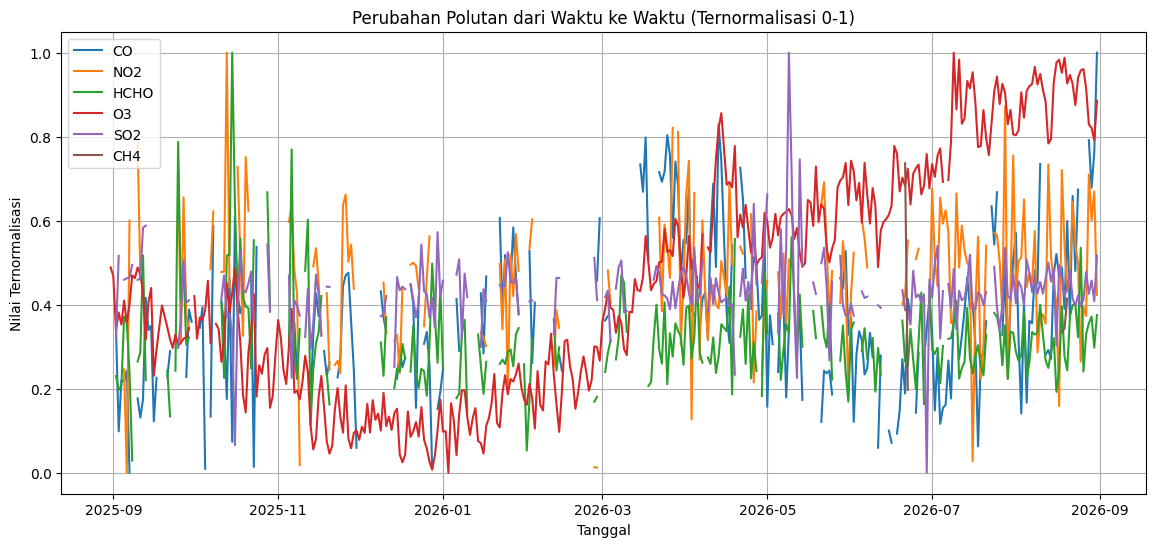

In [ ]:
df_normalisasi = df[POLLUTANTS].copy()

for polutan in POLLUTANTS:
    nilai_min = df_normalisasi[polutan].min()
    nilai_max = df_normalisasi[polutan].max()
    df_normalisasi[polutan] = (df_normalisasi[polutan] - nilai_min) / (nilai_max - nilai_min)

plt.figure(figsize=(14, 6))

for polutan in POLLUTANTS:
    plt.plot(df["date"], df_normalisasi[polutan], label=polutan)

plt.title("Perubahan Polutan dari Waktu ke Waktu (Ternormalisasi 0-1)")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Ternormalisasi")
plt.legend()
plt.grid()
plt.show()

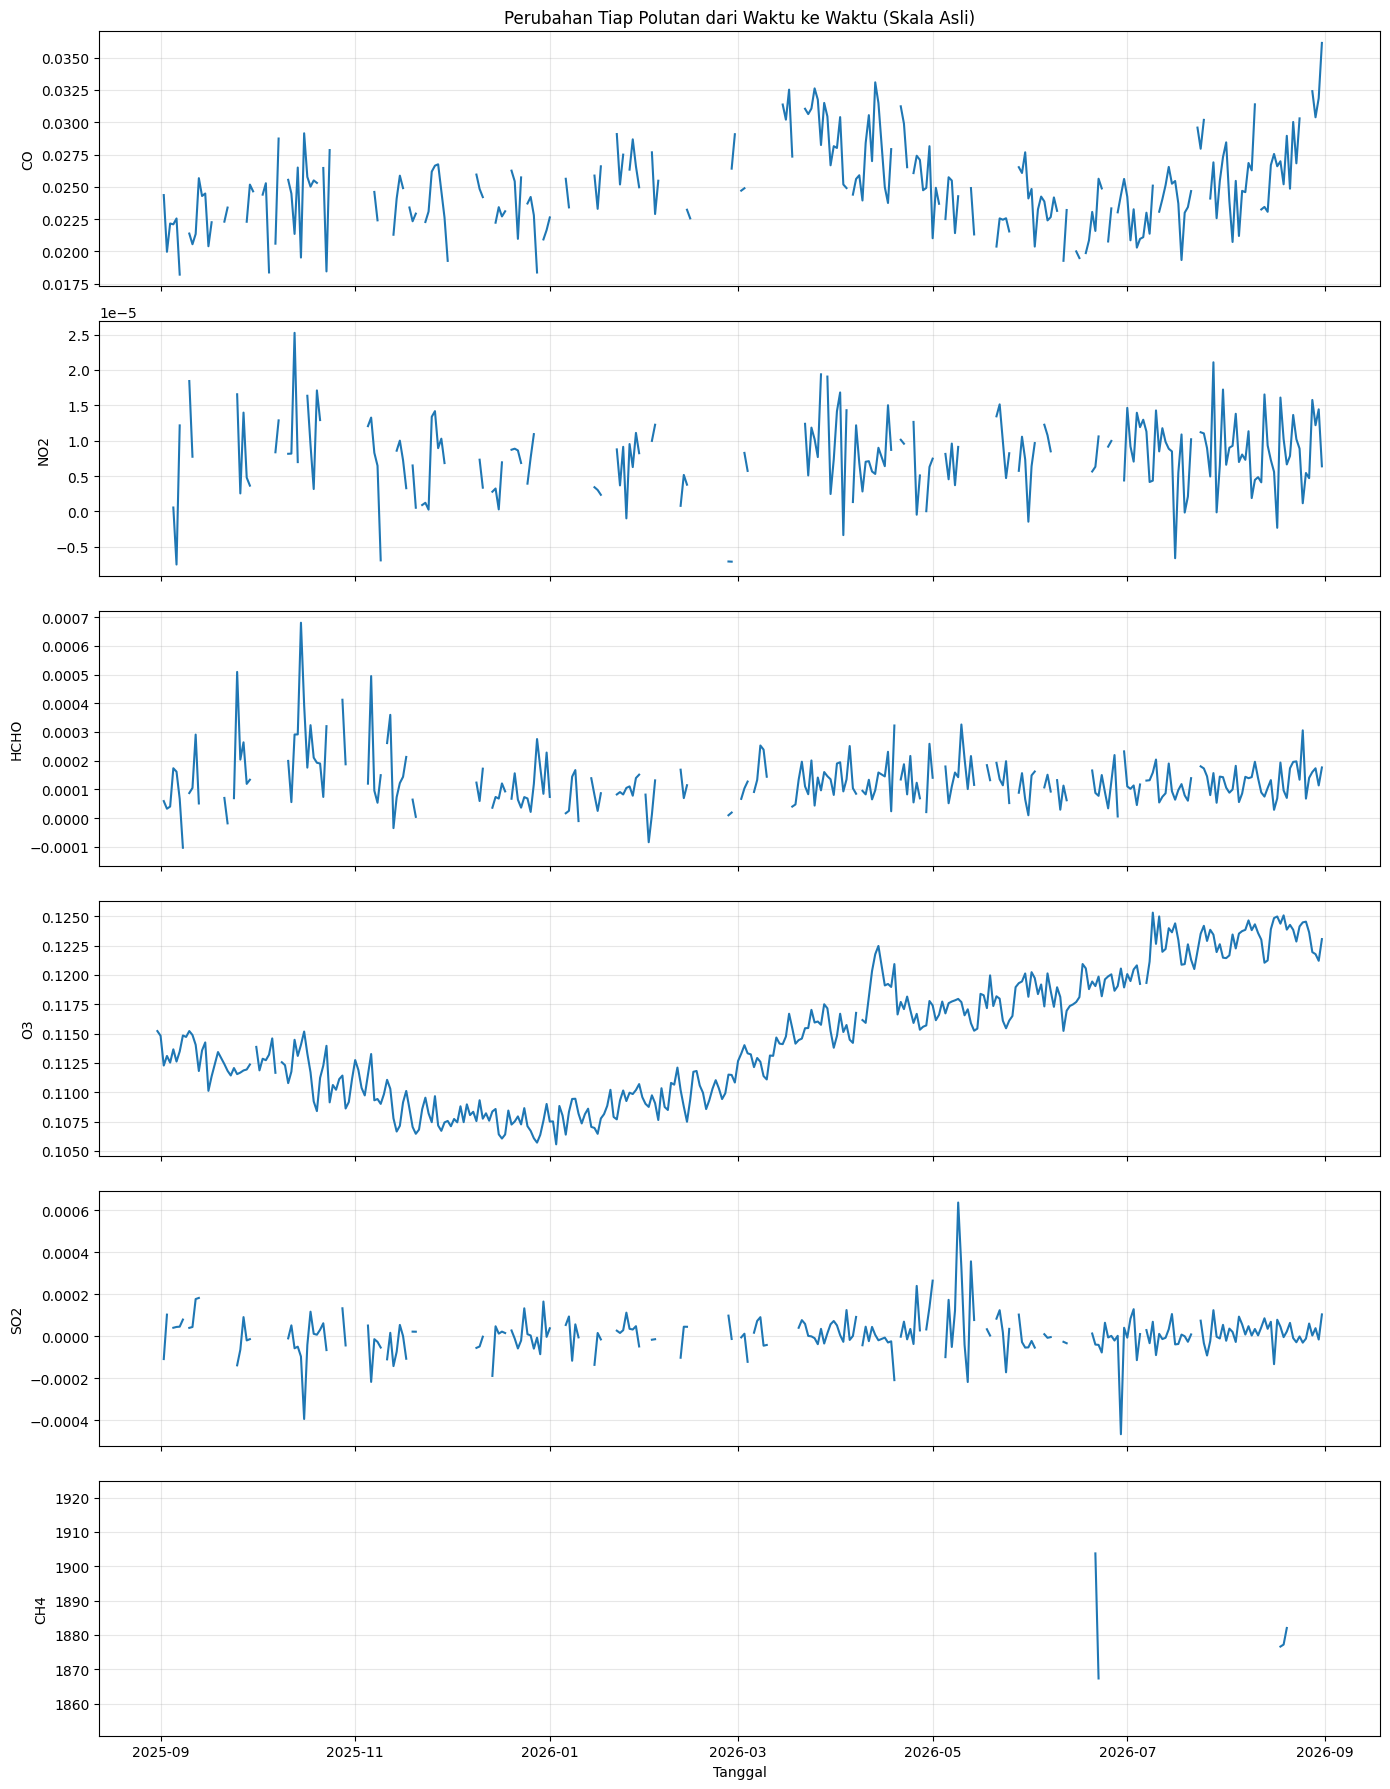

In [ ]:
fig, axes = plt.subplots(len(POLLUTANTS), 1, figsize=(14, 3 * len(POLLUTANTS)), sharex=True)

for ax, polutan in zip(axes, POLLUTANTS):
    ax.plot(df["date"], df[polutan], color="tab:blue")
    ax.set_ylabel(polutan)
    ax.grid(alpha=0.3)

axes[0].set_title("Perubahan Tiap Polutan dari Waktu ke Waktu (Skala Asli)")
axes[-1].set_xlabel("Tanggal")

plt.tight_layout()
plt.show()

**penjelasan code:**

* Grafik pertama menampilkan seluruh polutan yang telah dinormalisasi ke rentang 0–1, sehingga dapat ditumpuk dalam satu sumbu meskipun satuannya berbeda-beda.
* Grafik kedua memberikan subplot tersendiri untuk tiap polutan dengan nilai aslinya (tanpa normalisasi), agar CH4 yang datanya sangat terbatas tidak "tenggelam" di dalam grafik gabungan.

### 2.7 Penyimpanan Data ke Database (PostgreSQL — Aiven)

Selain disimpan sebagai file CSV, data polutan juga dipindahkan ke basis data PostgreSQL yang di-hosting di Aiven, sehingga dapat diakses ulang secara terpusat (misalnya dari KNIME atau aplikasi lain) tanpa bergantung pada file lokal.

Kredensial koneksi (host, port, password) disimpan melalui Colab Secrets, bukan ditulis langsung di kode, agar tidak ikut terekspos apabila notebook ini diunggah ke repositori publik.

In [ ]:
# membaca ulang CSV pollutant_data_manado.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("pollutant_data_manado.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("Polutan_manado", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "Polutan_manado" LIMIT 5', engine))

Berhasil! 364 baris terupload ke Aiven.
         date        CO       NO2      HCHO        O3       SO2   CH4
0  2025-08-31  0.025826  0.000003  0.000119  0.115216 -0.000039  None
1  2025-09-01       NaN       NaN       NaN  0.114812       NaN  None
2  2025-09-02  0.024364       NaN  0.000059  0.112275 -0.000109  None
3  2025-09-03  0.019973       NaN  0.000032  0.113091  0.000103  None
4  2025-09-04  0.022163       NaN  0.000040  0.112525       NaN  None


**penjelasan code:**

* `pd.read_csv(...)` membaca kembali berkas `pollutant_data_manado.csv` yang sudah dihasilkan sebelumnya.
* Kredensial (`AIVEN_USER`, `AIVEN_PASSWORD`, `AIVEN_HOST`, `AIVEN_PORT`, `AIVEN_DB`) diambil lewat `userdata.get()` dari Colab Secrets, bukan ditulis langsung, supaya tidak ikut terekspos kalau notebook ini dibagikan.
* `create_engine()` membentuk koneksi ke PostgreSQL Aiven memakai driver `psycopg2`, dengan `sslmode=require` karena Aiven mewajibkan koneksi terenkripsi.
* `df_baru.to_sql("Polutan_manado", engine, if_exists="replace", index=False)` mengirim seluruh isi dataframe ke tabel `Polutan_manado` di database; opsi `if_exists="replace"` berarti tabel lama (jika ada) akan ditimpa ulang.
* Dua baris `print()` terakhir hanya untuk verifikasi: menampilkan jumlah baris yang berhasil

### 2.8 Menarik Data dari PostgreSQL (Aiven) ke KNIME

Setelah data polutan tersimpan di basis data Aiven, langkah berikutnya adalah menariknya ke KNIME Analytics Platform untuk eksplorasi lebih lanjut. Alur kerja yang digunakan terdiri dari 4 node yang dihubungkan berurutan: **PostgreSQL Connector → DB Table Selector → DB Reader → Statistics**.

>![](https://cdn.mathpix.com/snip/images/Me4F2IO7mS_uXgzbmVwaMzt4rro_sh5m-rvbEjav6p0.original.fullsize.png)

**1. PostgreSQL Connector**

Node ini membuka koneksi ke server Aiven. Dua port merah (bulat) di bagian atas node adalah input opsional untuk kredensial lewat flow variable (mis. dari node **Credentials Configuration**, jika dipakai); jika tidak dihubungkan, username/password diisi langsung pada tab konfigurasi node ini. Parameter yang diisi:
- *Hostname*: sesuai `AIVEN_HOST` (ex: `pg-xxxxxxxx-postgrependata.f.aivencloud.com`)
- *Port*: sesuai `AIVEN_PORT` (ex: `10874`)
- *Database name*: `defaultdb`
- *Username / Password*: sesuai `AIVEN_USER` / `AIVEN_PASSWORD`
- *SSL Mode*: `require` (Aiven mewajibkan koneksi terenkripsi)

>![](https://cdn.mathpix.com/snip/images/co0ptxlZbn4apSZ3mhZoIVCkQOOLnjtGMokqgcQoQoo.original.fullsize.png)

**2. DB Table Selector**

Dihubungkan ke output PostgreSQL Connector (port merah kotak di sisi kanan node), lalu memilih tabel `Polutan_manado` yang sudah dibuat sebelumnya melalui `to_sql()`.

> ![](https://cdn.mathpix.com/snip/images/eKyK-cRqD3KTIBKa0StfzXvn97Kw9NtORatPgYjY5jk.original.fullsize.png)

**3. DB Reader**

Mengeksekusi query dari DB Table Selector dan mengubah hasilnya menjadi tabel KNIME biasa (port panah hitam di kanan node), sehingga siap diproses node analisis berikutnya.

> ![](https://cdn.mathpix.com/snip/images/qx1797h4nj--EbMJvwxJeFMomrGSwmFgz6fVjPYcvYE.original.fullsize.png)

**4. Statistics**

Dihubungkan langsung ke output DB Reader, menghitung ringkasan statistik (mean, median, std. deviation, variance, min, max, quartile, skewness, kurtosis, dll.) untuk tiap kolom polutan. Node ini punya 3 output port: *Statistics Table*, *Nominal Histogram Table*, dan *Occurrences Table*.

> ![](https://cdn.mathpix.com/snip/images/BF5LJPsz5q6ASh96uljXuZkt50q02Ox4ZZtBI09cQbQ.original.fullsize.png)

> ![](https://cdn.mathpix.com/snip/images/2FIe5juh4T1m-oOkIwsViwqWDAkQghh8EkfER2HL8M0.original.fullsize.png)

> ![](https://cdn.mathpix.com/snip/images/JurWGsjix5Cc51ruARFJpzAN74PH1c_GMOrg87m6nZg.original.fullsize.png)

Node ini menghasilkan beberapa informasi statistik, seperti:

- **Min** = nilai terkecil
- **Max** = nilai terbesar
- **Mean** = nilai rata-rata
- **Variance** = ukuran penyebaran data terhadap rata-rata
- **Std. Deviation** = standar deviasi
- **Skewness** = ukuran kemencengan distribusi data
- **Kurtosis** = ukuran keruncingan distribusi data
- **Overall Sum** = jumlah seluruh nilai
- **No. missings** = jumlah data yang kosong
- **No. NaNs** = jumlah data yang bernilai NaN
- **No. +oos** = jumlah data positif yang berada di luar batas
- **No. -oos** = jumlah data negatif yang berada di luar batas
- **Median** = nilai tengah data
- **Row Count** = jumlah seluruh baris data
- **Histogram** = visualisasi distribusi data

### 2.9 Contoh Perhitungan Statistics

Sebagai ilustrasi, diambil data kolom **CO** pada lima baris pertama:

| Hari | Tanggal | CO |
|---:|---|---:|
| 1 | 2025-08-31 | 0,025826 |
| 2 | 2025-09-01 | Missing |
| 3 | 2025-09-02 | 0,024364 |
| 4 | 2025-09-03 | 0,019973 |
| 5 | 2025-09-04 | 0,022163 |

Dari kelima baris tersebut, satu di antaranya kosong (missing), sehingga hanya empat nilai yang dipakai dalam perhitungan berikut:

$$
n=4
$$

$$
0,025826;\ 0,024364;\ 0,019973;\ 0,022163
$$

#### 1. Min

Min adalah nilai paling kecil di antara seluruh data yang tersedia.

$$
Min=\min(x_1,x_2,\ldots,x_n)
$$

Dari keempat nilai di atas:

$$
Min=\min(0,025826;\ 0,024364;\ 0,019973;\ 0,022163)=0,019973
$$

Sehingga **Min CO = 0,019973**.

#### 2. Max

Kebalikan dari Min, Max adalah nilai paling besar di antara data yang ada.

$$
Max=\max(x_1,x_2,\ldots,x_n)
$$

$$
Max=\max(0,025826;\ 0,024364;\ 0,019973;\ 0,022163)=0,025826
$$

Sehingga **Max CO = 0,025826**.

#### 3. Mean

Mean menggambarkan nilai tengah keseluruhan data, diperoleh dari total nilai dibagi banyaknya data.

$$
\bar{x}=\frac{\sum_{i=1}^{n}x_i}{n}
$$

$$
\bar{x}=\frac{0,025826+0,024364+0,019973+0,022163}{4}=\frac{0,092326}{4}=0,0230815
$$

Sehingga **Mean CO = 0,023082**.

#### 4. Variance

Variance menunjukkan besarnya penyebaran data terhadap nilai rata-ratanya. Pada contoh ini digunakan rumus *sample variance*:

$$
s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

Dengan $\bar{x}=0,0230815$, selisih tiap nilai terhadap mean beserta kuadratnya adalah sebagai berikut:

| $x_i$ | $x_i-\bar{x}$ | $(x_i-\bar{x})^2$ |
|---:|---:|---:|
| 0,025826 | 0,0027445 | 0,000007532 |
| 0,024364 | 0,0012825 | 0,000001645 |
| 0,019973 | -0,0031085 | 0,000009663 |
| 0,022163 | -0,0009185 | 0,000000844 |

Jumlah seluruh kuadrat selisih tersebut:

$$
\sum(x_i-\bar{x})^2\approx0,000019684
$$

sehingga:

$$
s^2=\frac{0,000019684}{4-1}\approx0,000006561
$$

Diperoleh **Variance CO ≈ 0,000006561**.

#### 5. Std. Deviation

Standar deviasi merupakan akar dari variance, dan lebih mudah diinterpretasikan karena satuannya sama dengan data aslinya.

$$
s=\sqrt{s^2}=\sqrt{0,000006561}\approx0,002561
$$

Diperoleh **Std. Deviation CO ≈ 0,002561**.

#### 6. Skewness

Skewness mengukur tingkat kemencengan (asimetri) distribusi data. Perhitungan berikut menggunakan rumus *corrected sample skewness*:

$$
G_1=\frac{n}{(n-1)(n-2)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^3
$$

Dengan $n=4$, $\bar{x}=0,0230815$, dan $s\approx0,002561$, diperoleh:

$$
G_1\approx-0,319
$$

Nilai **Skewness CO ≈ -0,319** ini bertanda negatif, menandakan distribusi data sedikit condong ke arah kiri.

#### 7. Kurtosis

Kurtosis menggambarkan tingkat keruncingan distribusi dibandingkan distribusi normal, dihitung dengan rumus *corrected sample excess kurtosis*:

$$
G_2=\frac{n(n+1)}{(n-1)(n-2)(n-3)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^4-\frac{3(n-1)^2}{(n-2)(n-3)}
$$

Dengan $n=4$, hasil perhitungannya:

$$
G_2\approx-1,613
$$

Nilai **Kurtosis CO ≈ -1,613** yang negatif ini mengindikasikan bahwa distribusi data lebih datar dibandingkan distribusi normal.

#### 8. Overall Sum

Overall Sum adalah total penjumlahan seluruh nilai numerik yang tersedia pada kolom tersebut.

$$
Sum=\sum_{i=1}^{n}x_i
$$

$$
Sum=0,025826+0,024364+0,019973+0,022163=0,092326
$$

Sehingga **Overall Sum CO = 0,092326**.

#### 9. No. Missings

Fitur ini mencatat jumlah baris yang tidak memiliki nilai (kosong) pada kolom tersebut. Dari total 5 baris, hanya 4 yang terisi data CO, sehingga:

$$
No.\ missings=1
$$

#### 10. No. NaNs

Berbeda dari missing value, No. NaNs khusus menghitung nilai yang secara eksplisit bertipe *Not a Number*. Pada contoh ini tidak ditemukan nilai semacam itu:

$$
No.\ NaNs=0
$$

#### 11. No. +oos

Fitur ini menunjukkan banyaknya nilai positif yang berada di luar batas (*out of spec*) yang ditetapkan. Tidak ada data pada contoh ini yang termasuk kategori tersebut:

$$
No.\ +oos=0
$$

#### 12. No. -oos

Sebaliknya, fitur ini menghitung nilai negatif yang berada di luar batas yang ditetapkan. Pada contoh ini juga tidak ditemukan data semacam itu:

$$
No.\ -oos=0
$$

#### 13. Median

Median merupakan nilai yang berada tepat di tengah setelah data diurutkan. Data yang telah diurutkan:

$$
0,019973;\ 0,022163;\ 0,024364;\ 0,025826
$$

Karena jumlah data genap (n = 4), median diambil dari rata-rata dua nilai tengah:

$$
Median=\frac{x_{n/2}+x_{n/2+1}}{2}=\frac{0,022163+0,024364}{2}=\frac{0,046527}{2}=0,0232635
$$

Sehingga **Median CO = 0,023264**.

#### 14. Row Count

Row Count menghitung seluruh baris pada tabel, termasuk yang bernilai missing. Pada contoh ini terdapat 5 baris:

$$
Row\ Count=5
$$

Perlu digarisbawahi bahwa Row Count tidak sama dengan jumlah data yang dipakai dalam perhitungan Mean, Variance, dan statistik numerik lainnya, karena nilai yang missing tidak diikutsertakan dalam perhitungan tersebut.